In [7]:
import pathlib
import pandas as pd
from autoreject import AutoReject
import mne
import numpy as np
from pathlib import Path 
from specparam import SpectralGroupModel


from pesco.io import load_sources

In [3]:
PROJECT_PATH = '/Users/daniel/PhD/spectral-comparison/code'
PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")
path = pathlib.Path(PROJECT_PATH)
DATA_PATH = pathlib.Path(PROJECT_PATH)
raw, channels = load_sources(str(DATA_PATH / 'data/Mantini2018/'), specific=1)

Creating RawArray with float64 data, n_channels=76, n_times=59983
    Range : 0 ... 59982 =      0.000 ...   299.910 secs
Ready.


In [12]:
data= raw.copy().crop(1., 20.)
event_time=np.arange(200, data.n_times, 400)
code=np.zeros(len(event_time))
code[::2] = 2
code[1::2] = 1
events= np.array([event_time,np.zeros(len(event_time)), code]).T
event_id = {'Auditory/Left': 1, 'Auditory/Right': 2}
tmin, tmax = -0.2, 0.5

Using matplotlib as 2D backend.


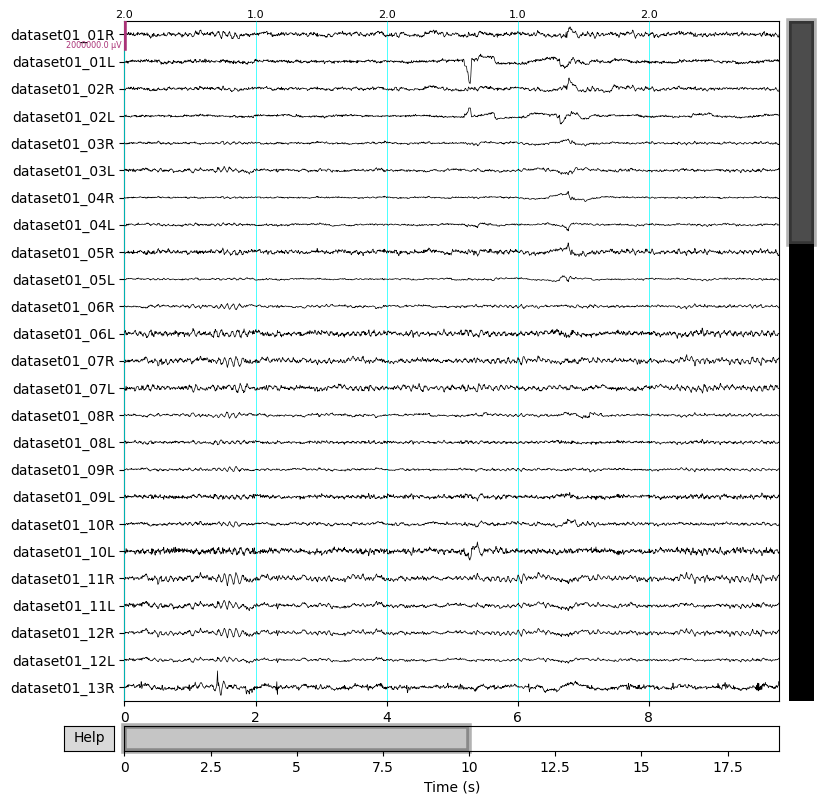

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 10.240 (s)
Plotting power spectral density (dB=True).


/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_19191/1871455720.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  k = data.plot_psd(picks= np.arange(0,15,1),fmin=3, fmax=40)
/Users/daniel/PhD/spectral-comparison/code/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


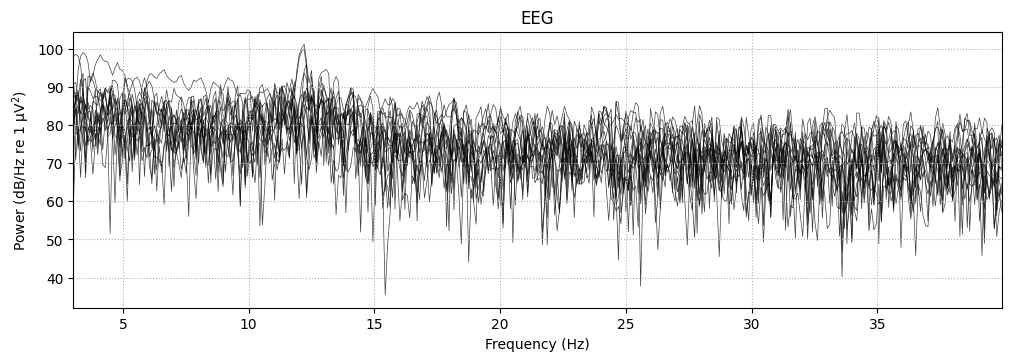

In [13]:
scalings = 'auto'
events= np.array([event_time,np.zeros(len(event_time)), code]).T
data.plot(events=events, n_channels=25, scalings=scalings, title='Auto-scaled Data from arrays',       show=True, block=True)
# %%
k = data.plot_psd(picks= np.arange(0,15,1),fmin=3, fmax=40)

In [14]:
# %%
tmin, tmax = -1, 1
events_id = dict(odd=1, even=2)
epochs = mne.Epochs(data, events.astype(int), event_id, tmin, tmax, proj=True,
                       baseline=None,                       preload=True, reject=None )

Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 10 events and 401 original time points ...
1 bad epochs dropped


In [15]:
data.info['bads'] = []
picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False,
                       include=[], exclude=[])
#%%

data.info['bads'] = []
picks = mne.pick_types(data.info, meg=False, eeg=True, stim=False, eog=False,
                      include=[], exclude=[])
ar = AutoReject(n_interpolates, consensus_percs, picks=picks,
               thresh_method='random_search', random_state=42)

ar.fit(epochs['odd'])
epochs_clean = ar.transform(epochs['odd'])
evoked_clean = epochs_clean.average()
evoked = epochs['odd'].average()


ar.get_reject_log(epochs['Auditory/Left']).plot()

%%

In [17]:
n_interpolates = np.array([1, 4, 8])
consensus_percs = np.linspace(0, 1.0, 11)
raw.del_proj()  # remove all projectors

<RawArray | 76 x 59983 (299.9 s), ~34.8 MiB, data loaded>

In [18]:
ar = AutoReject(n_interpolates, consensus_percs, picks=picks,
                thresh_method='bayesian_optimization', random_state=42, verbose = 'tqdm')

In [21]:
list(epochs.event_id.keys())   # ['odd', 'even']


['Auditory/Left', 'Auditory/Right']

In [22]:
# Note that fitting and transforming can be done on different compatible
# portions of data if needed.
ar.fit(epochs['Auditory/Left'])
epochs_clean = ar.transform(epochs['Auditory/Left'])
evoked_clean = epochs_clean.average()
evoked = epochs['Auditory/Left'].average()

    # Same `dev_head_t` for all runs so that we can concatenate them.

RuntimeError: Valid channel positions are needed for autoreject to work

raw2 , chan_details2 = preprocess.load_sources(str(path) + '/data/Mantini2018/')

event_id = dict(odd=1, even=2)
tmin = -1
info =data.info

custom_epochs = mne.EpochsArray(data, info, events, tmin, event_id)
mne.viz.plot_events(events, data.info['sfreq'], data.first_samp,                   event_id=event_id)

In [8]:
# %%
from IPython import get_ipython 
ip = get_ipython()
ip.run_line_magic('load_ext', 'autoreload')
ip.run_line_magic('autoreload', '2')
# %matplotlib inline

import pandas as pd
import mne as mne
import numpy as np
from numpy.lib.stride_tricks import as_strided

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 5]

# %%
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    """ short time fourier transform of audio signal """
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))
    samples = np.array(sig, dtype='float64')
    cols = np.ceil((len(samples) - frameSize) / float(hopSize)) + 1
    frames = as_strided(
        samples,
        shape=(cols, frameSize),
        strides=(samples.strides[0] * hopSize, samples.strides[0])).copy()
    frames *= win
    return np.fft.rfft(frames)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
raw, channels = load_sources(str(DATA_PATH / "data/Mantini2018/"), specific=1)

# %%
# Compute segments
tmin, tmax = 10, 130

fmin, fmax = 3, 80
# PSD settings
srate = raw.info["sfreq"]
n_fft, n_overlap, n_per_seg = int(2 * srate), int(srate), int(2 * srate)
data, times = raw[:]
Fs = raw.info["sfreq"]

psd = raw.compute_psd(
    method="welch",
    fmin=fmin,
    fmax=fmax,
    tmin=tmin,
    tmax=tmax,
    n_fft=n_fft,
    n_overlap=n_overlap,
    n_per_seg=n_per_seg,
    verbose=False,
)
spectrum = psd.get_data()
freqs = psd.freqs
psd_df = pd.DataFrame(spectrum, index=channels["region_number"])

fg = SpectralGroupModel(peak_width_limits=[1, 8], min_peak_height=0.05, max_n_peaks=6)
fg.fit(freqs, psd_df.values, freq_range=[3, 40], n_jobs=-1)

# extracting data from fg.results (specparam 2.0 API)
results = fg.results
temp_df = pd.DataFrame()
temp_df["sls"] = [r.aperiodic_fit[-1] for r in results]  # exponent
temp_df["errors"] = [r.metrics["error_mae"] for r in results]
temp_df["r2s"] = [r.metrics["gof_rsquared"] for r in results]
temp_df["ch_number"] = np.arange(len(channels))

# peaks: variable number per channel
all_peaks = []
for ch_idx, r in enumerate(results):
    if r.peak_fit.size > 0:
        for peak in r.peak_fit.reshape(-1, 3):
            all_peaks.append([*peak, ch_idx])
peaks_df = pd.DataFrame(all_peaks, columns=["CF", "Amp", "BW", "ch_number"])

channels["ch_number"] = np.arange(len(channels))
peaks_all = (
    channels
    .set_index("ch_number")
    .join(peaks_df.set_index("ch_number"))
    .join(temp_df.set_index("ch_number"))
)

# %%
X = np.arange(2, int(data.shape[1] / srate - 60), 30)
Y = X + 60


Creating RawArray with float64 data, n_channels=76, n_times=59983
    Range : 0 ... 59982 =      0.000 ...   299.910 secs
Ready.
Fitting model across 76 power spectra.
